In [1]:
from pathlib import Path
import torch
from torch import nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Paths
DATA_DIR  = Path("/home/rishi/medai/data/chest-xray-pneumonia/chest-pneumonia/archive/chest_xray/chest_xray")
MODEL_PATH = Path("../models/resnet18_baseline.pth")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [2]:
# Deterministic transforms for evaluation — no augmentation
eval_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load the held-out test set — never seen during training
test_ds     = datasets.ImageFolder(DATA_DIR / "test", transform=eval_tfms)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print("Test size:", len(test_ds))
print("Class mapping:", test_ds.class_to_idx)

Test size: 624
Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


In [3]:
# Rebuild architecture and load saved weights
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 1)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

print("Model loaded.")

Model loaded.


In [4]:
all_probs  = []
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)  # Convert logits to probabilities

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend((probs > 0.5).long().cpu().numpy())  # Binary prediction at threshold 0.5
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("Inference complete. Total samples:", len(all_labels))

Inference complete. Total samples: 624


In [5]:
# AUC-ROC: threshold-independent measure of separability
auc = roc_auc_score(all_labels, all_probs)

# Full breakdown: precision, recall (sensitivity), f1 per class
report = classification_report(all_labels, all_preds,
                                target_names=["NORMAL", "PNEUMONIA"])

# Extract sensitivity and specificity manually
tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
sensitivity = tp / (tp + fn)  # Of all real pneumonia, how many did we catch?
specificity = tn / (tn + fp)  # Of all real normal, how many did we correctly clear?

print(f"AUC-ROC:     {auc:.4f}")
print(f"Sensitivity: {sensitivity:.4f}  (pneumonia recall)")
print(f"Specificity: {specificity:.4f}  (normal recall)")
print()
print(report)

AUC-ROC:     0.9649
Sensitivity: 0.9923  (pneumonia recall)
Specificity: 0.7735  (normal recall)

              precision    recall  f1-score   support

      NORMAL       0.98      0.77      0.87       234
   PNEUMONIA       0.88      0.99      0.93       390

    accuracy                           0.91       624
   macro avg       0.93      0.88      0.90       624
weighted avg       0.92      0.91      0.91       624



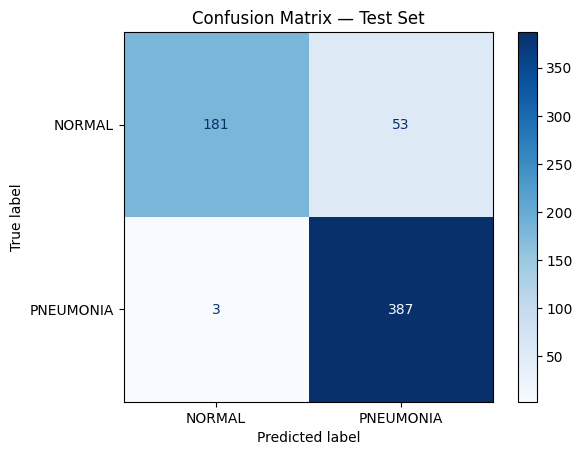

TN: 181 | FP: 53 | FN: 3 | TP: 387


In [6]:
# Visual confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["NORMAL", "PNEUMONIA"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set")
plt.savefig("../outputs/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("TN:", tn, "| FP:", fp, "| FN:", fn, "| TP:", tp)

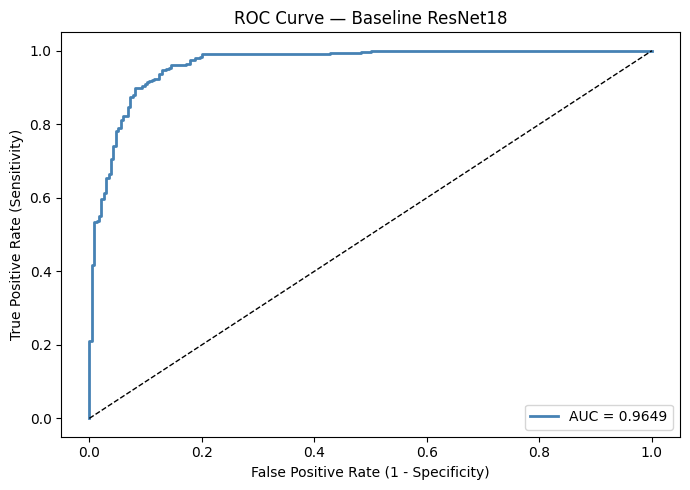

In [7]:
# ROC curve — shows tradeoff between sensitivity and specificity at all thresholds
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", color="steelblue", lw=2)
plt.plot([0, 1], [0, 1], "k--", lw=1)  # Random chance baseline
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve — Baseline ResNet18")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()